In [43]:
import neo4j
import re

from plotnine.themes.elements import element_blank
from plotnine.themes.themeable import axis_title_y
from tqdm.notebook import tqdm
import pandas as pd
from neo4j import GraphDatabase, Driver, Query
import os
import glob

from typing import Literal
from pathlib import Path
from plotnine import *
import matplotlib as mpl
import numpy as np
import duckdb

from mizani.transforms import symlog_trans
from mizani.formatters import scientific_format

mpl.rcParams['mathtext.fontset'] = 'custom'
mpl.rcParams['mathtext.rm'] = 'Libertinus Serif' # Roman
mpl.rcParams['mathtext.it'] = 'Libertinus Serif:italic' # Italic
mpl.rcParams['mathtext.bf'] = 'Libertinus Serif:bold' # Bold

In [2]:
def get_driver(database: Literal["neo4j", "memgraph"], port: int = 0) -> Driver:
    server = "vulcan.dbai.tuwien.ac.at"
    if database == "neo4j":
        return GraphDatabase.driver(f"bolt://{server}:{port}", auth=("neo4j", "password"))
    elif database == "memgraph":
        return GraphDatabase.driver(f"bolt://{server}:7688", auth=(None, None))


In [3]:
NO_RUNS = 10

Execute the following cell for each database, graph, query, and state:

In [4]:
database = "memgraph"
#database = "neo4j"
port = 7687
scenario = "S_Lon"
#state = "before"
state = "after"
#mode = "retrieval"
#mode = "update"

results: list[dict] = []
for i in tqdm(range(NO_RUNS)):
    modes = ["retrieval","update"]

    for mode in modes:
        if mode == "retrieval":
            all_queries = {
                "S_Off-1" : {
                    "before": [["PROFILE MATCH (e:Entity) WHERE e.countries IS NOT NULL AND e.jurisdiction_description IS NOT NULL AND e.country_codes IS NOT NULL RETURN DISTINCT e.countries, e.country_codes"],
                               ["PROFILE MATCH (e:Entity) WHERE e.countries IS NOT NULL AND e.service_provider IS NOT NULL AND e.country_codes IS NOT NULL RETURN DISTINCT e.countries,e.service_provider, e.country_codes"]],
                    "after": [
                        ["PROFILE MATCH (c:EcountriesecountryCodes) WHERE c.Ecountries IS NOT NULL AND c.EcountryCodes IS NOT NULL RETURN DISTINCT c.Ecountries, c.EcountryCodes",
                         "PROFILE MATCH (:Entity)-[]->(c:EcountriesecountryCodes) WHERE c.Ecountries IS NOT NULL AND c.EcountryCodes IS NOT NULL RETURN DISTINCT c.Ecountries, c.EcountryCodes"],
                        ["PROFILE MATCH (e:Entity)-[]-(c:EcountriesecountryCodes) WHERE c.Ecountries IS NOT NULL AND c.EcountryCodes IS NOT NULL RETURN DISTINCT c.Ecountries, c.EcountryCodes, e.service_provider"]
                    ]
                },
                "S_Ts-2": {
                    "before": [["PROFILE MATCH ()-[t:STOPS_AT]->(s:Station) WHERE s.name IS NOT NULL AND t.code IS NOT NULL RETURN DISTINCT t.code, s.name"],
                               ['PROFILE MATCH (ts:TrainService)-[t:STOPS_AT]->(s:Station) WHERE ts.type CONTAINS "Nightjet" RETURN DISTINCT ts.number, ts.type, t.code'],
                               ['PROFILE MATCH (ts:TrainService) WHERE ts.type CONTAINS "Nightjet" RETURN DISTINCT ts.number, ts.completely_cancelled'],
                               ['PROFILE MATCH (ts:TrainService) WHERE ts.type CONTAINS "Sprinter" RETURN DISTINCT ts.number, ts.operator']],
                    "after": [["PROFILE MATCH (n:Snametcode) RETURN DISTINCT n.Sname, n.Tcode", "PROFILE MATCH (s:Station)-->(n:Snametcode), (t:STOPS_AT)-->(n), (t)-->(s) RETURN DISTINCT n.Sname, n.Tcode" ],
                              ['PROFILE MATCH (ts:TrainService)-->(t:STOPS_AT)-->(s:Station), (ts)-->(d:Tsdatetsnumbertstype), (s)-->(n:Snametcode), (t)-->(n) WHERE d.Tstype CONTAINS "Nightjet" RETURN DISTINCT d.Tsnumber, d.Tstype, n.Tcode'],
                              ['PROFILE MATCH (ts:TrainService)-->(d:Tsdatetsnumbertstype) WHERE d.Tstype CONTAINS "Nightjet" RETURN DISTINCT d.Tsnumber, ts.completely_cancelled'],
                              ['PROFILE MATCH (ts:TrainService)-->(d:Tsdatetsnumbertstype), (ts)-->(e:Tsdatetsnumbertsoperator) WHERE d.Tstype CONTAINS "Sprinter" RETURN DISTINCT d.Tsnumber, e.Tsoperator', 'PROFILE MATCH (ts:TrainService)-->(d:Tsdatetsnumbertstype), (ts)-->(e:Tsdatetsnumbertsoperator) WHERE d.Tstype CONTAINS "Sprinter" RETURN DISTINCT d.Tsnumber, e.Tsoperator']]
                },
                "S_Nw": {
                    "before": [["PROFILE MATCH (o:Order) RETURN DISTINCT o.orderID, o.customerID"],
                               ["PROFILE MATCH (o:Order) WHERE o.customerID IS NOT NULL AND o.shipCity IS NOT NULL AND o.shipPostalCode IS NOT NULL AND o.shipCountry IS NOT NULL AND o.shipAddress IS NOT NULL AND o.shipRegion IS NOT NULL RETURN DISTINCT o.customerID"]],
                    "after": [["PROFILE MATCH (o:Order)-[]-(c:OcustomerIDoshipAddressoshipCityoshipCountryoshipPostalCodeoshipRegion) RETURN DISTINCT o.orderID, c.OcustomerID"],
                              ["PROFILE MATCH (o:OcustomerIDoshipAddressoshipCityoshipCountryoshipPostalCodeoshipRegion) WHERE o.OcustomerID IS NOT NULL AND o.OshipCity IS NOT NULL AND o.OshipPostalCode IS NOT NULL AND o.OshipCountry IS NOT NULL AND o.OshipAddress IS NOT NULL AND o.OshipRegion IS NOT NULL RETURN DISTINCT o.OcustomerID",
                               "PROFILE MATCH (:Order)-->(o:OcustomerIDoshipAddressoshipCityoshipCountryoshipPostalCodeoshipRegion) WHERE o.OcustomerID IS NOT NULL AND o.OshipCity IS NOT NULL AND o.OshipPostalCode IS NOT NULL AND o.OshipCountry IS NOT NULL AND o.OshipAddress IS NOT NULL AND o.OshipRegion IS NOT NULL RETURN DISTINCT o.OcustomerID"]]
                },
                "S_Lon": {
                    "before": [["PROFILE MATCH ()-[c:CONNECTED_THROUGH]->() RETURN DISTINCT c.line, c.color"],
                          ['PROFILE MATCH (s:Station)-[c:CONNECTED_THROUGH]-() WHERE s.name = "Piccadilly Circus" RETURN DISTINCT c.line'],
                          ['PROFILE MATCH (s:Station) WHERE s.zoneOriginal IS NOT NULL RETURN DISTINCT s.zone, s.zoneOriginal'],
                          ['PROFILE MATCH (s:Station)-[c:CONNECTED_THROUGH]-(:Station) WHERE s.zone = "6" RETURN DISTINCT c.line'],
                          ['PROFILE MATCH (s:Station)-[c:CONNECTED_THROUGH]->(t:Station) WHERE s.name = "Piccadilly Circus" AND c.line = "Bakerloo" RETURN DISTINCT s.name, t.name']
                          ],
                    "after": [["PROFILE MATCH (c:Ccolorclinectype) RETURN DISTINCT c.Cline, c.Ccolor",
                               "PROFILE MATCH  ()-[]-(d:CONNECTED_THROUGH)-[]-(), (d)-[]-(c:Ccolorclinectype) RETURN DISTINCT c.Cline, c.Ccolor"],
                              ['PROFILE MATCH (s:Station)-[]-(:CONNECTED_THROUGH)-[:CCOLORCLINECTYPE]-(c:Ccolorclinectype) WHERE s.name = "Piccadilly Circus" RETURN DISTINCT c.Cline'],
                              ['PROFILE MATCH (s:SzoneszoneOriginal) WHERE s.SzoneOriginal IS NOT NULL RETURN DISTINCT s.Szone, s.SzoneOriginal', 'PROFILE MATCH (s:Station)-[]-(s:SzoneszoneOriginal) WHERE s.SzoneOriginal IS NOT NULL RETURN DISTINCT s.Szone, s.SzoneOriginal'],
                              ['PROFILE MATCH (s:Station)-[]-(c:CONNECTED_THROUGH)-[]-(:Station), (s)-[]-(z:SzoneszoneOriginal), (c)-[]-(d:Ccolorclinectype) WHERE z.Szone = "6" RETURN DISTINCT d.Cline'],
                              ['PROFILE MATCH (s:Station)-[]->(c:CONNECTED_THROUGH)-[]->(t:Station), (c)-[]-(d:Ccolorclinectype) WHERE s.name = "Piccadilly Circus" and d.Cline ="Bakerloo" RETURN t.name']]
                }
            }
        else:
            all_queries = {
                "S_Off-1" : {
                    "before": [[f'PROFILE MATCH (e:Entity) WHERE e.countries IS NOT NULL AND e.jurisdiction_description IS NOT NULL AND e.country_codes IS NOT NULL AND e.countries = "Singapore" SET e.country_codes = "Sp"']],
                    "after": [ ['PROFILE MATCH (c:EcountriesecountryCodes) WHERE c.Ecountries IS NOT NULL AND c.EcountryCodes IS NOT NULL AND c.Ecountries = "Singapore" SET c.EcountryCodes = "Sp"',
                         'PROFILE MATCH (:Entity)-[]->(c:EcountriesecountryCodes) WHERE c.Ecountries IS NOT NULL AND c.EcountryCodes IS NOT NULL AND c.Ecountries = "Singapore" SET c.EcountryCodes = "Sp"',
                                'PROFILE MATCH (:Entity)-[]->(c:EcountriesecountryCodes) WHERE c.Ecountries IS NOT NULL AND c.EcountryCodes IS NOT NULL AND c.Ecountries = "Singapore" WITH DISTINCT c SET c.EcountryCodes = "Sp"'],],
                },
                "S_Ts-2": {
                    "before": [[f'PROFILE MATCH ()-[t:STOPS_AT]->(s:Station) WHERE s.name IS NOT NULL AND t.code IS NOT NULL AND s.name = "Innsbruck Hbf" SET t.code = "Rainbow"']],
                    "after": [['PROFILE MATCH (n:Snametcode) WHERE n.Sname = "Innsbruck Hbf" SET n.Tcode = "Rainbow"',
                               'PROFILE MATCH (s:Station)-->(n:Snametcode), (t:STOPS_AT)-->(n), (t)-->(s) WHERE n.Sname = "Innsbruck Hbf" SET n.Tcode = "Rainbow"',
                               'PROFILE MATCH (s:Station)-->(n:Snametcode), (t:STOPS_AT)-->(n), (t)-->(s) WHERE n.Sname = "Innsbruck Hbf" WITH DISTINCT n  SET n.Tcode = "Rainbow"']],
                },
                "S_Nw": {
                    "before": [[f'PROFILE MATCH (o:Order) WHERE o.customerID = "FOLKO" SET o.shipCountry = "Rainbow"']],
                    "after": [[f'PROFILE MATCH (o:Order)-[]-(c:OcustomerIDoshipAddressoshipCityoshipCountryoshipPostalCodeoshipRegion) WHERE c.OcustomerID = "FOLKO" SET c.OshipCountry = "Rainbow"',
                               f'PROFILE MATCH (o:Order)-[]-(c:OcustomerIDoshipAddressoshipCityoshipCountryoshipPostalCodeoshipRegion) WHERE c.OcustomerID = "FOLKO" WITH DISTINCT c SET c.OshipCountry = "Rainbow"',
                               f'PROFILE MATCH (c:OcustomerIDoshipAddressoshipCityoshipCountryoshipPostalCodeoshipRegion) WHERE c.OcustomerID = "FOLKO" SET c.OshipCountry = "Rainbow"',]],
                },
                "S_Lon": {
                    "before": [[f'PROFILE MATCH ()-[c:CONNECTED_THROUGH]->() WHERE c.line = "Bakerloo" SET c.color = "Rainbow"']],
                    "after": [[f'PROFILE MATCH (c:Ccolorclinectype) WHERE c.Cline = "Bakerloo" SET c.Ccolor = "Rainbow"',
                               f'PROFILE MATCH (:CONNECTED_THROUGH)-->(c:Ccolorclinectype) WHERE c.Cline = "Bakerloo" SET c.Ccolor = "Rainbow"',
                               'PROFILE MATCH (:CONNECTED_THROUGH)-->(c:Ccolorclinectype) WHERE c.Cline = "Bakerloo" WITH DISTINCT c SET c.Ccolor = "Rainbow"']],
                },
            }

        queries = all_queries[scenario][state]

        j = 1
        while j <= len(queries):
            query_group = queries[j-1]

            for query in tqdm(query_group):
                with get_driver(database).session() as s:
                    if database == "neo4j":
                        s.run("CALL db.clearQueryCaches()")


                    q = Query(query)
                    result = s.run(q)

                    time: float = 0
                    """in milliseconds"""
                    hits: int = 0
                    memory: int = 0

                    if database == "neo4j":
                        summary: neo4j.ResultSummary

                        _, summary, _ = result.to_eager_result()

                        time: float = 0

                        def get_time(profile: dict):
                            if "time" in profile.keys():
                                return profile["time"]
                            elif "children" in profile.keys():
                                acc = 0
                                for child in profile["children"]:
                                    acc += get_time(child)
                                return acc
                            else:
                                return 0

                        time = get_time(summary.profile)

                        time = time / (10**6)

                        lines = [line.strip() for line in summary.profile["args"]["string-representation"].strip().split('\n') if line.strip()]
                        summary_line = lines[-1]
                        print(summary_line)


                        all_numbers = re.findall(r"\d+", summary_line)

                        hits = int(all_numbers[0]) if len(all_numbers) > 0 else 0
                        memory = int(all_numbers[1]) if len(all_numbers) > 1 else 0


                    elif database == "memgraph":
                        summary: neo4j.ResultSummary

                        result, _, _ = result.to_eager_result()

                        hits = 0
                        time = 0
                        for record in result:
                            hits += record[1]
                            time += float(record[3][:-3].strip())
                        memory = None

                    results.append({"scenario":scenario, "queryNo": j, "query": query, "state": state, "mode": mode, "database": database, "time": time, "dbhits": hits, "memory": memory})
            j+= 1


rdf = pd.DataFrame(results)
filepath = Path(f'out/queries/{scenario}__{database}__{state}.csv')
filepath.parent.mkdir(parents=True, exist_ok=True)
rdf.to_csv(f"out/queries/{scenario}__{database}__{state}.csv", sep=",", index=None)

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

...

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

## Figures

In [37]:
all_files = glob.glob(os.path.join("out/queries", "*.csv"))

df = pd.concat((pd.read_csv(f) for f in all_files), ignore_index=True)
df = df.groupby(["scenario", "queryNo","database","query","state","dbhits","mode"], as_index=False).mean(numeric_only=True)
df['plot_category'] = df['mode'] + " " + "$"+df['scenario'].astype(str).str.replace("_","_\\text{") + "}$; Query " + df['queryNo'].astype(str) + "; " + df['database'].astype(str).str.capitalize()


#df = df[df["scenario"]=="S_Lon"]

state_order = ['before', 'after']

df['state'] = pd.Categorical(df['state'], categories=state_order, ordered=True)

df.to_csv("out/query_aggregated.csv")

query_results_pivoted = duckdb.query("""SELECT DISTINCT df.scenario, df.mode, df.queryNo, 'direct?' as direct, 'optimized?' as optimized,
                                round(beforeM.time, 2) as timeBeforeMemgraph, round(beforeN.time, 2) as timeBeforeNeo4j, round(afterM.time, 2) as timeAfterMemgraph, round(afterN.time, 2) as timeAfterNeo4j,
    beforeM.dbhits as hitsBeforeMemgraph, beforeN.dbhits as hitsBeforeNeo4j, afterM.dbhits as hitsAfterMemgraph, afterN.dbhits as hitsAfterNeo4j
                FROM df
             JOIN df AS beforeM ON df.scenario = beforeM.scenario AND df.mode = beforeM.mode AND df.queryNo = beforeM.queryNo
             JOIN df AS beforeN ON df.scenario = beforeN.scenario AND df.mode = beforeN.mode AND df.queryNo = beforeN.queryNo
             JOIN df AS afterM ON df.scenario = afterM.scenario AND df.mode = afterM.mode AND df.queryNo = afterM.queryNo
             JOIN df AS afterN ON df.scenario = afterN.scenario AND df.mode = afterN.mode AND df.queryNo = afterN.queryNo AND afterM.query = afterN.query
WHERE beforeN.database = 'neo4j' AND beforeN.state = 'before' AND
beforeM.database = 'memgraph' AND beforeM.state = 'before' AND
afterN.database = 'neo4j' AND afterN.state = 'after' AND
afterM.database = 'memgraph' AND afterM.state = 'after' ORDER BY df.scenario, df.mode, df.queryNo
            """).to_df()

query_results_pivoted.to_csv("out/query_results_pivoted.csv")




/Users/jschrott/Repositories/global-lpg-norm/.venv/lib/python3.13/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 12.0 x 6.5 cm image.
/Users/jschrott/Repositories/global-lpg-norm/.venv/lib/python3.13/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: out/fig7_query_dbhits.pdf


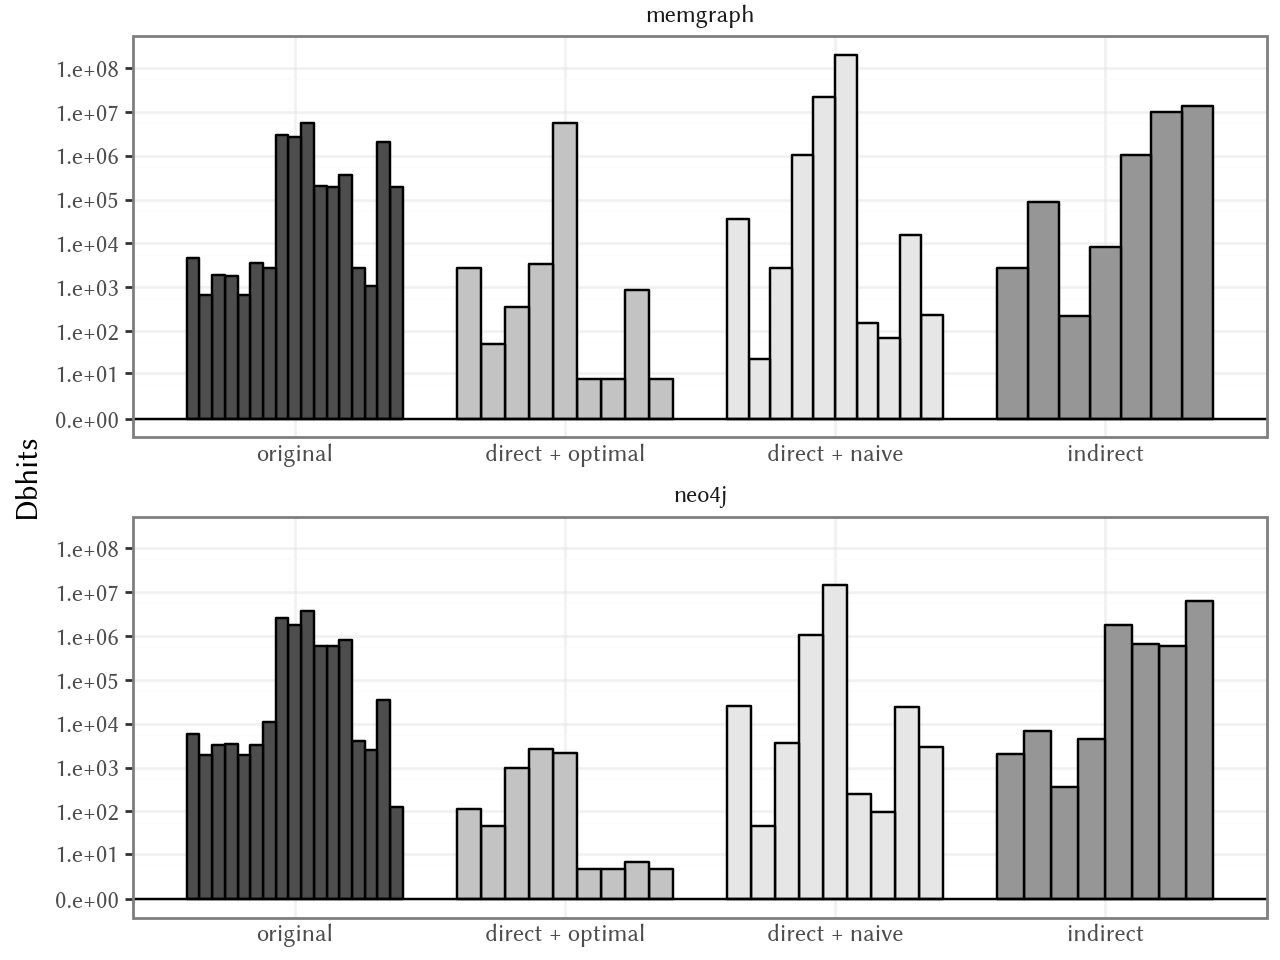

In [57]:
classified_results = pd.read_csv("out/query_aggregated_classified.csv")
plot1 = (
    ggplot(classified_results, aes(x='type', y='dbhits', fill='type', group="plot_category"))
   # + geom_col(color="black", position='dodge', width=0.8)
    + stat_summary(
        fun_y=np.max,
        geom='col',
        color="black",
        position='dodge',
        width=0.8
    )
    + geom_hline(yintercept=0, color="black")
    + scale_fill_grey(start=0.9, end=0.3)
    + scale_y_continuous(trans="symlog",labels=scientific_format(), limits=(0,200000000))
    + scale_x_discrete(limits=['original', 'direct + optimal', 'direct + naive', 'indirect'])

#    + facet_grid(('scenario','queryNo'), 'database' , scales='free_y')
    + facet_wrap("~ database", scales="free_x", ncol=1)
    + labs(
        y="Dbhits",
    )
    + theme_bw()
    + theme(text=element_text(family='Libertinus Sans'),
            plot_background=element_rect(fill='white'),
            axis_title_x=element_blank(),
            axis_ticks_major_x=element_blank(),
            #axis_text_x=element_blank(),
            legend_position='none',
                                    strip_background = element_blank(),
            panel_spacing = 0.025,
            legend_margin=5,
            plot_margin_top= 0.01)
)

plot1.save("out/fig7_query_dbhits.pdf", width=12, height=6.5, units="cm")
plot1.show()

/Users/jschrott/Repositories/global-lpg-norm/.venv/lib/python3.13/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 12.0 x 2.5 cm image.
/Users/jschrott/Repositories/global-lpg-norm/.venv/lib/python3.13/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: out/fig7_query_dbhits_direct + optimal.pdf


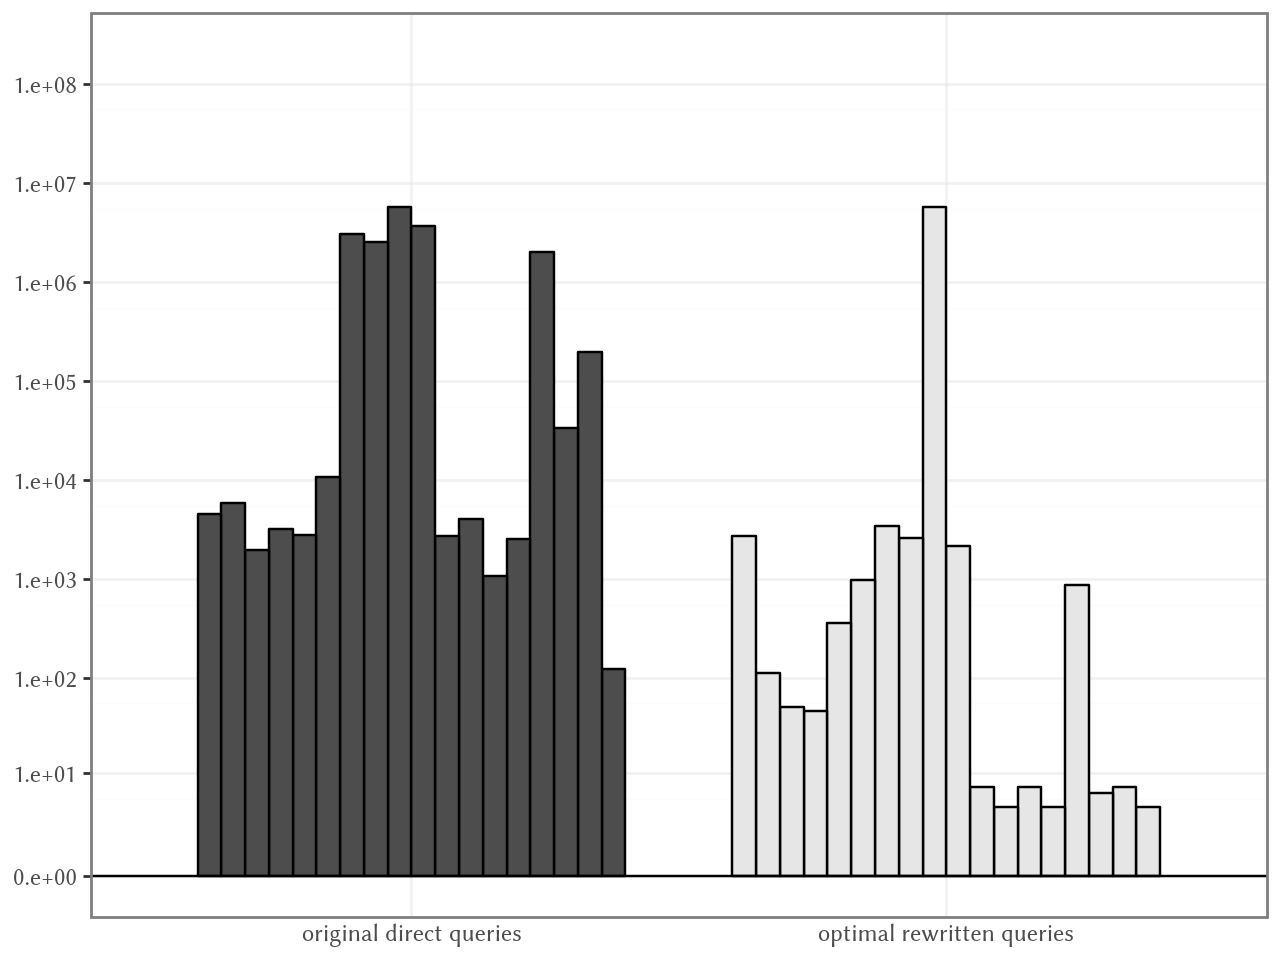

/Users/jschrott/Repositories/global-lpg-norm/.venv/lib/python3.13/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 12.0 x 2.5 cm image.
/Users/jschrott/Repositories/global-lpg-norm/.venv/lib/python3.13/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: out/fig7_query_dbhits_direct + naive.pdf


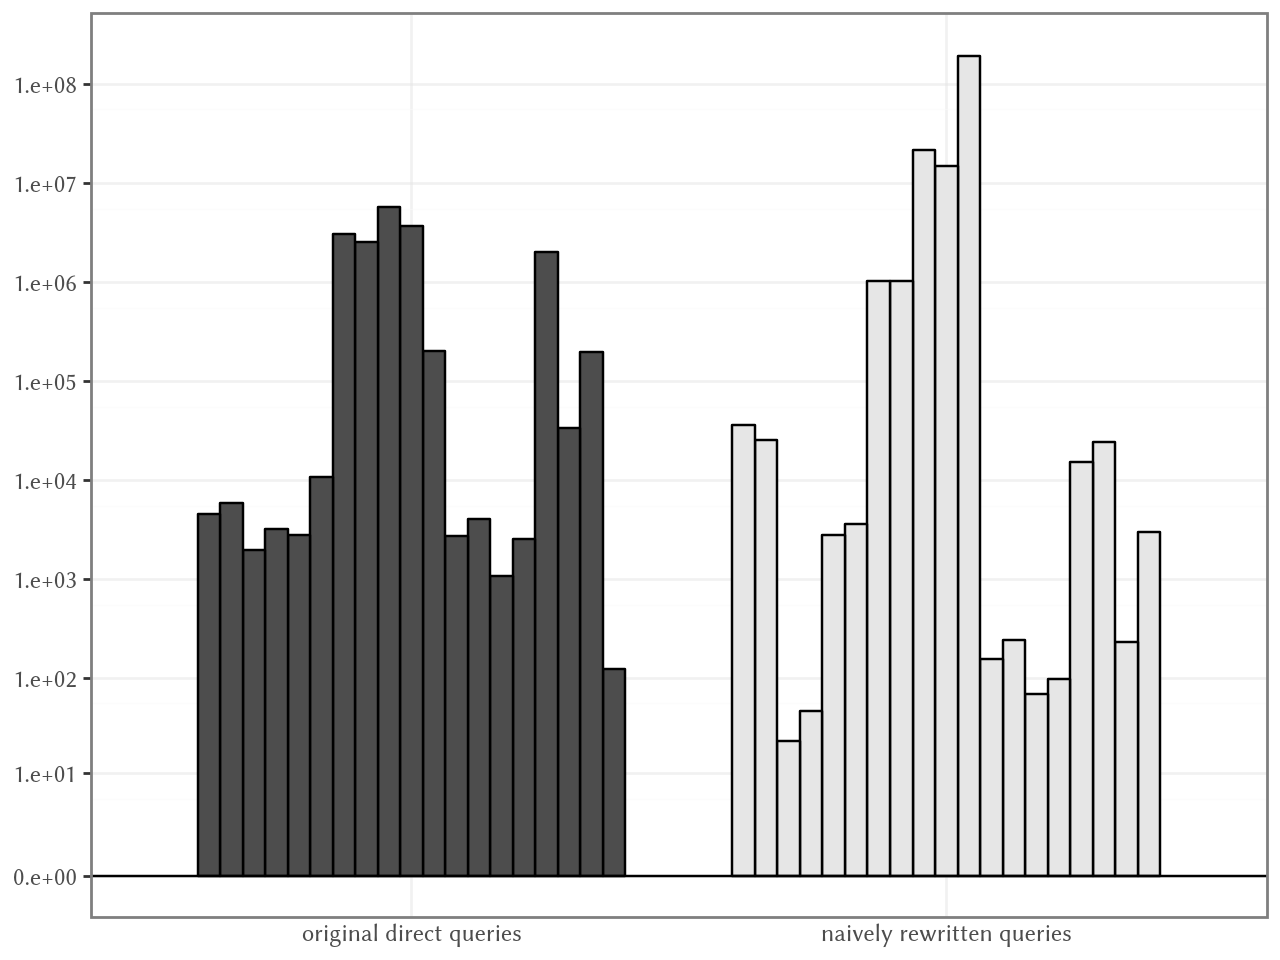

/Users/jschrott/Repositories/global-lpg-norm/.venv/lib/python3.13/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 12.0 x 2.5 cm image.
/Users/jschrott/Repositories/global-lpg-norm/.venv/lib/python3.13/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: out/fig7_query_dbhits_indirect.pdf


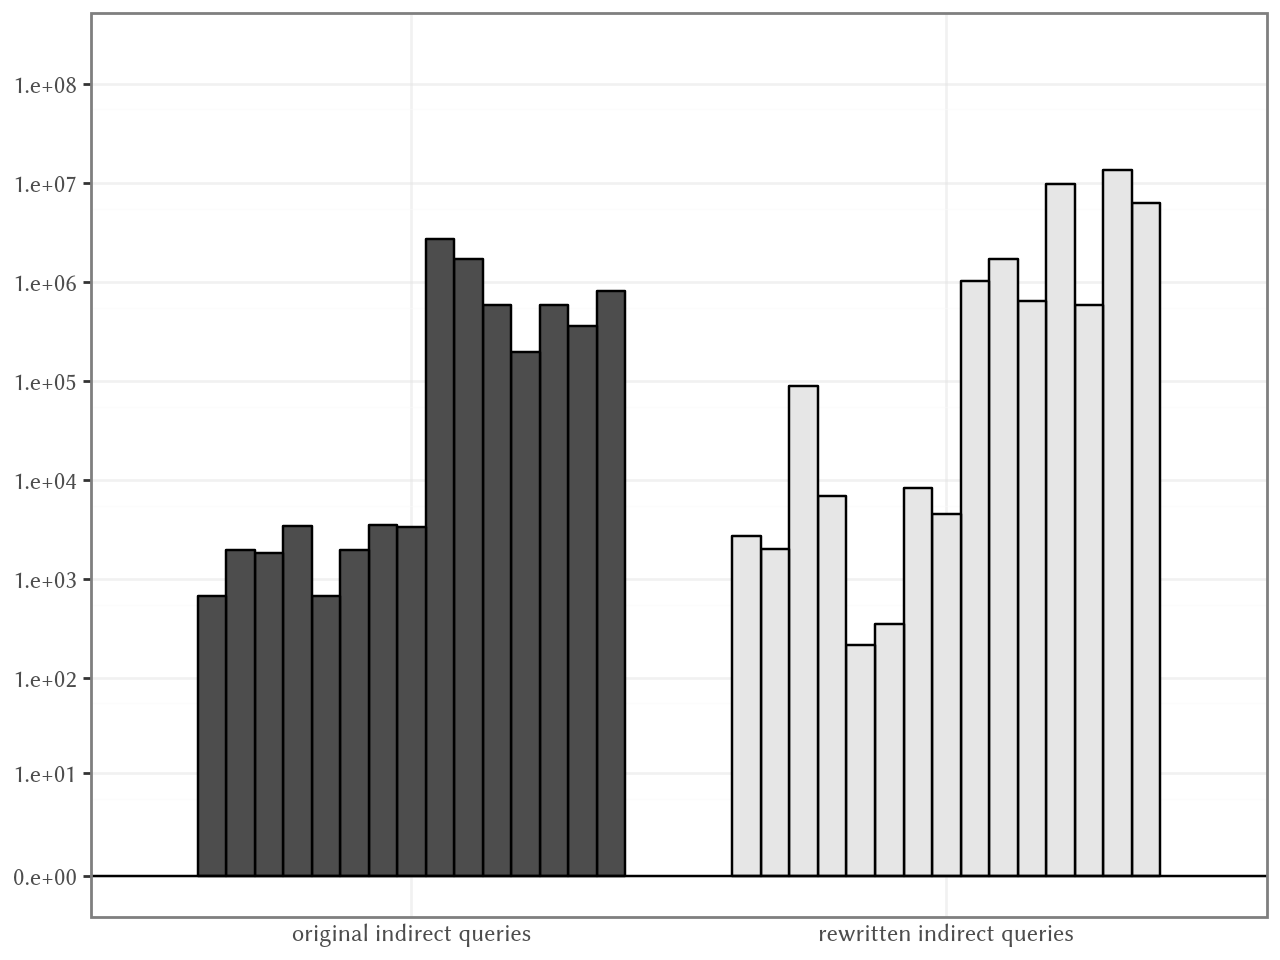

In [65]:
classified_results = pd.read_csv("out/query_aggregated_classified.csv")
for f in ["direct + optimal", "direct + naive", "indirect"]:
    classified_results_filtered = duckdb.query("""
    SELECT DISTINCT c.\"type", c.dbhits, c.plot_category, c.database FROM classified_results as c
          JOIN classified_results as d ON c.plot_category = d.plot_category WHERE (c.\"type\" = 'original' AND d.\"type\" = $1) or c.\"type\" = $1
                                               """, params=[f]).to_df()

    if " + " in f:
        first_group = "original direct queries"
    else:
        first_group = "original indirect queries"

    if "optimal" in f:
        second_group = "optimal rewritten queries"
    elif "naive" in f:
        second_group = "naively rewritten queries"
    else:
        second_group = "rewritten indirect queries"
    plot1 = (
        ggplot(classified_results_filtered, aes(x='type', y='dbhits', fill='type', group="plot_category"))
       # + geom_col(color="black", position='dodge', width=0.8)
        + stat_summary(
            fun_y=np.max,
            geom='col',
            color="black",
            position='dodge',
            width=0.8
        )
        + geom_hline(yintercept=0, color="black")
        + scale_fill_grey(start=0.9, end=0.3)
        + scale_y_continuous(trans="symlog",labels=scientific_format(), limits=(0,200000000))
        + scale_x_discrete(limits=["original", f], labels=[first_group, second_group])


    #    + facet_grid(('scenario','queryNo'), 'database' , scales='free_y')
      #  + facet_wrap("~ database", scales="free_x", ncol=1)
        + labs(
            y="Dbhits",
        )
        + theme_bw()
        + theme(text=element_text(family='Libertinus Sans'),
                plot_background=element_rect(fill='white'),
                axis_title_x=element_blank(),
                axis_title_y=element_blank(),
                axis_ticks_major_x=element_blank(),
                #axis_text_x=element_blank(),
                legend_position='none',
                                        strip_background = element_blank(),
                panel_spacing = 0.025,
                legend_margin=5,
                plot_margin_top= 0.01)
    )

    plot1.save(f"out/fig7_query_dbhits_{f}.pdf", width=12, height=2.5, units="cm")
    plot1.show()

In [14]:
     plot1 = (
    ggplot(df, aes(x='state', y='time', fill='state', group="query"))
    + geom_col(color="black", position='dodge', width=0.5)
    #+ geom_hline(yintercept=0, color="black")
    + scale_fill_grey(start=0.9, end=0.3)
    #+ scale_y_continuous(trans="symlog", limits=(-100,3000))
#    + facet_grid(('scenario','queryNo'), 'database' , scales='free_y')
    + facet_wrap("~ plot_category", scales="free", ncol=2)
    + labs(
        y="Execution time (in milliseconds)",
    )
    + theme_bw()
    + theme(text=element_text(family='Libertinus Sans'),
            plot_background=element_rect(fill='white'),
            axis_title_x=element_blank(),
            axis_ticks_major_x=element_blank(),
            legend_position='none')
)

plot1.save("out/query_times.pdf", width=12, height=60, units="cm")
plot1.show()

NameError: name 'df' is not defined

In [ ]:
plot1 = (
    ggplot(df, aes(x='state', y='dbhits', fill='state', group="query"))
    + geom_col(color="black", position='dodge', width=0.5)
    #+ geom_hline(yintercept=0, color="black")
    + scale_fill_grey(start=0.9, end=0.3)
    #+ scale_y_continuous(trans="symlog", limits=(-100,3000))
#    + facet_grid(('scenario','queryNo'), 'database' , scales='free_y')
    + facet_wrap("~ plot_category", scales="free", ncol=2)
    + labs(
        y="Database hits",
    )
    + theme_bw()
    + theme(text=element_text(family='Libertinus Sans'),
            plot_background=element_rect(fill='white'),
            axis_title_x=element_blank(),
            axis_ticks_major_x=element_blank(),
            legend_position='none')
)

plot1.save("out/query_dbhits.pdf", width=12, height=60, units="cm")
plot1.show()

In [ ]:
all_files = glob.glob(os.path.join("out/queries", "*.csv"))

df = pd.concat((pd.read_csv(f) for f in all_files), ignore_index=True)
df = df[["time","dbhits", "database"]]
df["database"] = df["database"].str.capitalize()

In [ ]:
plot = (
    ggplot(df, aes(x='time', y='dbhits', color="database", shape="database"))
    + geom_point( size=1)
   # + geom_text(aes(label='round(value, 2)'), size=8)  # Optional: add values
 #   + scale_fill_gradient2(low="blue", mid="white", high="red", midpoint=0)
    + theme(axis_text_x=element_text(rotation=45, hjust=1))
+ scale_y_continuous(trans="symlog")
+ scale_x_continuous(trans="symlog")
    + theme_bw()

    + labs(title="", x="Execution time (in milliseconds; logarithmic scale)", y="Database hits (logarithmic scale)", fill="Corr", color="Graph system:",  # Custom title for the color scale
        shape="Graph system:" )  # Must match to merge the legends)
    + theme(text=element_text(family='Libertinus Sans'),
            plot_background=element_rect(fill='white'),
            axis_ticks_major_x=element_blank(),
            legend_position=(0.905, 0.11),
            legend_background=element_rect(
                color='gray',
                size=0.5,
                fill='white',
            ),
            legend_margin=5,
            )
)
plot
plot.save("out/query_correlation.pdf", width=12, height=8, units="cm")
plot.show()